In [109]:
# Utils
# ==============================================================================
import warnings

# Plot
# ==============================================================================
import pandas as pd
import numpy as np

# Data Preprocessing
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (OneHotEncoder, LabelEncoder)


# Data Pipe
# ==============================================================================
from sklearn.compose import ColumnTransformer


# Model
# ==============================================================================
from sklearn.model_selection import train_test_split, ParameterGrid, GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance


# Metrics
# ==============================================================================
from sklearn.metrics import recall_score

# **Info**
---

**@By:** Steven Bernal

**@Nickname:** Kaiziferr

**@Git:** https://github.com/Kaiziferr

# **Context**
---

The Sleep Health and Lifestyle Dataset is a dataset that includes detailed information on sleep health and daily habits of 400 individuals. It consists of 13 variables, including demographic aspects, sleep metrics, physical activity, stress levels, and cardiovascular parameters.

# **Data dictionary**
---


- Person ID: Un identificador único para cada individuo.

- Gender: El género de la persona (Masculino/Femenino).

- Age: La edad de la persona en años.

- Occupation: La ocupación o profesión de la persona.

- Sleep Duration (hours): El número de horas que la persona duerme al día.

- Quality of Sleep (scale: 1-10): Una calificación subjetiva de la calidad del sueño, en una escala del 1 al 10.

- Physical Activity Level (minutes/day): El número de minutos que la persona dedica a la actividad física diaria.

- Stress Level (scale: 1-10): Una calificación subjetiva del nivel de estrés experimentado por la persona, en una escala del 1 al 10.

- BMI Category: La categoría de IMC de la persona (por ejemplo, Bajo peso, Normal, Sobrepeso).

- Blood Pressure (systolic/diastolic): La medición de la presión arterial de la persona, indicada como presión sistólica sobre presión diastólica.

- Heart Rate (bpm): La frecuencia cardíaca en reposo de la persona en latidos por minuto.

- Daily Steps: El número de pasos que la persona camina al día.

- Sleep Disorder: La presencia o ausencia de un trastorno del sueño en la persona (Ninguno, Insomnio, Apnea del sueño).


# **Objectives**
---
- Predict the presence or absence of a sleep disorder in an individual (None, Insomnia, Sleep Apnea).

# **Utils**
---

# **Config**
---

In [110]:
random_seed = 12354
warnings.filterwarnings('ignore')
title_data = 'Financial Data'
paleta = sns.color_palette('tab10').as_hex()

# **Data**
---

https://drive.google.com/file/d/17O-fj_s_Yyvz2frIyubx4_AhPx0bRdKk/view?usp=sharing

https://drive.google.com/file/d/13FPmxqyJnP8witp7zU0VsU7CcArzQxXF/view?usp=sharing

In [111]:
url='https://drive.google.com/file/d/17O-fj_s_Yyvz2frIyubx4_AhPx0bRdKk/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
data = pd.read_csv(url)

In [112]:
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# **Exploratory Data Analysis (EDA)**
---

In [113]:
data = data.drop(columns=['Person ID'])

The Person ID column is removed because it does not add value, as it only represents the index of the records.

In [114]:
new_columns = ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']
data.columns = new_columns

Rename the variables for better understanding.

**Variable types**

In [115]:
data.shape

(374, 12)

There are 400 rows and 12 columns.

In [116]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Blood Pressure           374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 35.2+ KB


The dataset contains 5 object-type features, 5 integer features, and 2 float features.

**Missing data**

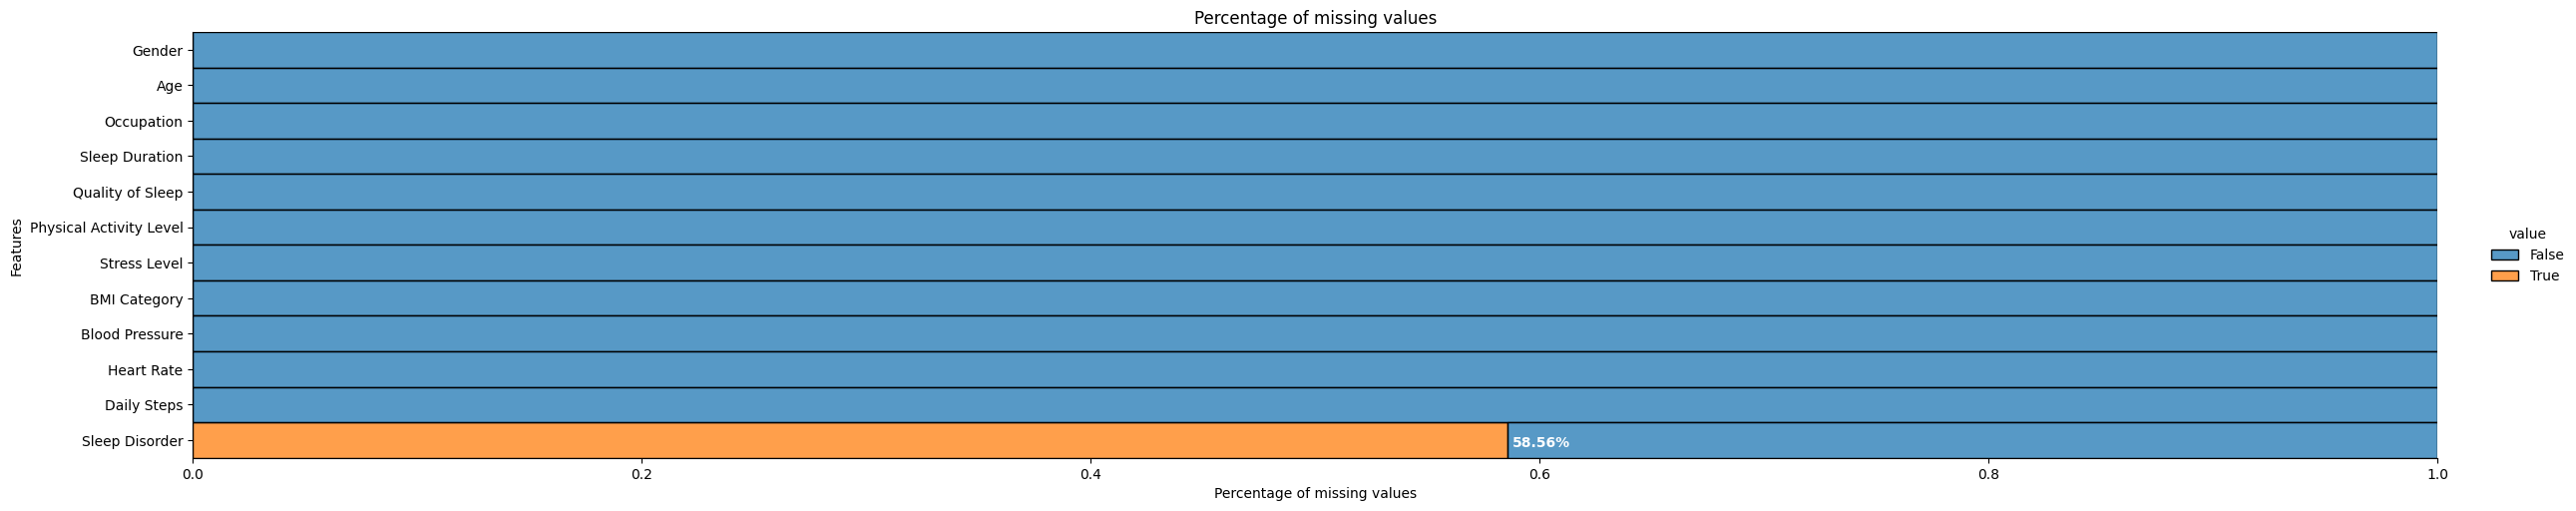

In [117]:
null_percentage_per_feature(data, title="Percentage of missing values", xlabel='Percentage of missing values', ylabel='Features')

There are no null values in the dataset. The missing values do not actually represent nulls; instead, they indicate that no sleep disorder was present.

In [118]:
data['Sleep Disorder'] = data['Sleep Disorder'].fillna('None')

**Constants**

In [119]:
isConstan_object = data.describe(include='object').loc['unique']
isConstan_object = isConstan_object[isConstan_object == 1]
isConstan_object

,unique


In [120]:
isConstan_numeric = data.describe().loc['std']
isConstan_numeric[isConstan_numeric<=0]

,std


The dataset does not contain any constant features.

# **Univariate EDA**

In [121]:
data.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


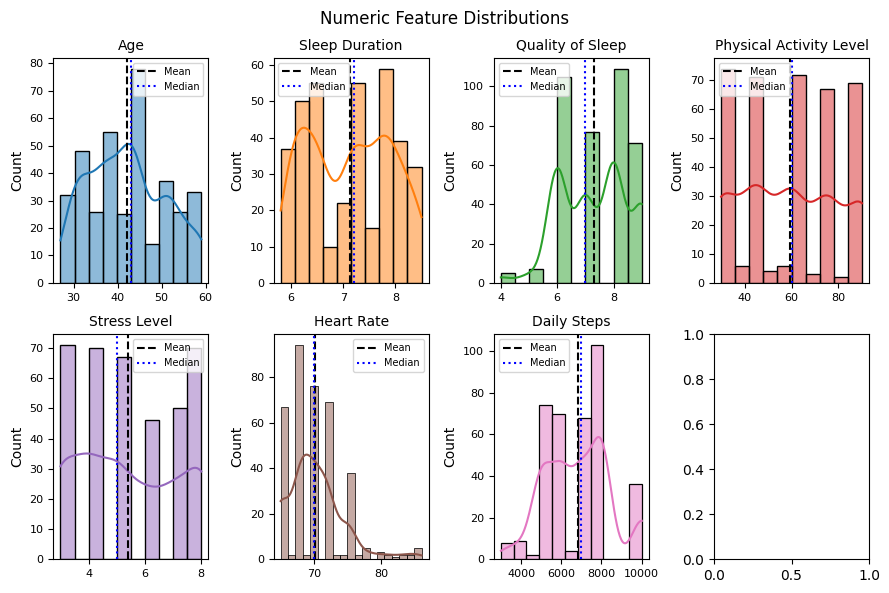

In [122]:
plot_numeric_distributions(data, 2, 4, palette=None, show_stats=['mean', 'median'])

**Age**

- Center: Mean ≈ 42.2, median ≈ 43 the distribution is well-centered.
- Dispersion: Range from 27 to 59, with relatively high standard deviation (~8.7).
- Shape: Approximately symmetric, though slightly irregular.
- Insight: No strong skewness; age is well distributed across young to middle-aged adults.

**Sleep Duration**

- Center: Mean ≈ 7.13, median ≈ 7.2 very close values.
- Dispersion: Low (std ≈ 0.8), range between 5.8 and 8.5 hours.
- Shape: Compact and close to a normal distribution.
- Insight: Most individuals sleep between 6 and 8 hours, aligning with recommended ranges.

**Quality of Sleep**

- Center: Mean ≈ 7.31, median ≈ 7.
- Dispersion: Moderate (std ≈ 1.2), values between 4 and 9.
- Shape: Slight right skew (higher-value concentration).
- Insight: Higher density between 6 and 8, with few low-quality sleep cases.

**Physical Activity Level**

- Center: Mean ≈ 59.2, median ≈ 60.
- Dispersion: High (std ≈ 20.8), wide range (30 to 90).
- Shape: Relatively uniform/dispersed, without a clear dominant peak.
- Insight: Significant inter-individual variability in activity levels.

**Stress Level**

- Center: Mean ≈ 5.39, median ≈ 5.
- Dispersion: Moderate (std ≈ 1.77), range between 3 and 8.
- Shape: Fairly balanced, with mild concentration around mid-values.
- Insight: Mid-range stress levels (4–7) are most common.

**Heart Rate**

- Center: Mean ≈ 70.2, median ≈ 70.
- Dispersion: Low to moderate (std ≈ 4.1), range 65–86 bpm.
- Shape: Positively skewed (right tail).
- Insight: Slight skew toward higher values suggests some individuals may exhibit elevated physiological activation, potentially associated with stress or poorer sleep quality.

**Daily Steps**

- Center: Mean ≈ 6817, median ≈ 7000.
- Dispersion: High (std ≈ 1618), wide range (3000–10000).
- Shape: Slight left skew (mean < median).
- Insight: Higher concentration between 6000 and 8000 steps, indicating moderate daily activity levels.

In [123]:
def categorize_bp(bp):
    systolic, diastolic = map(int, bp.split("/"))

    if systolic >= 180 or diastolic >= 120:
        return "Hypertensive Crisis"
    elif systolic >= 140 or diastolic >= 90:
        return "Hypertension Stage 2"
    elif systolic >= 130 or diastolic >= 80:
        return "Hypertension Stage 1"
    elif systolic >= 120 and diastolic < 80:
        return "Elevated"
    else:
        return "Normal"

In [124]:
data["BP Category"] = data["Blood Pressure"].apply(categorize_bp)

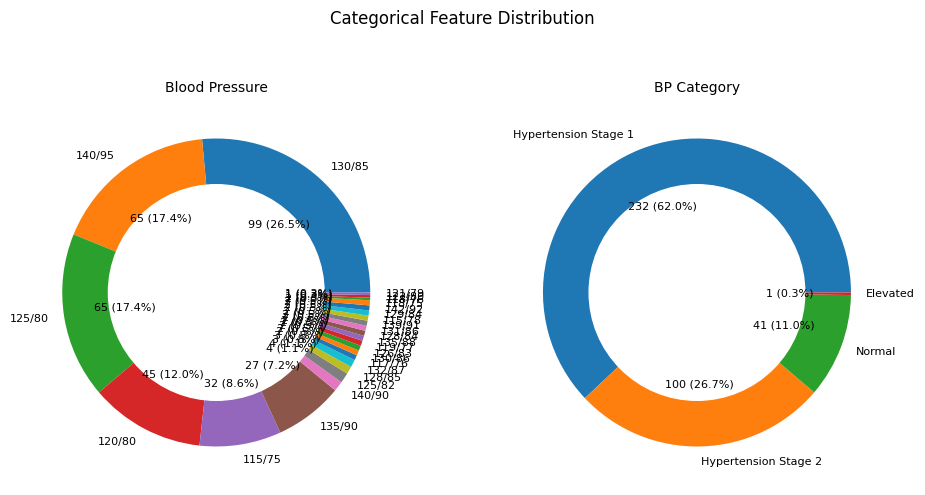

In [125]:
plot_categorical_donut_charts(data[['Blood Pressure', 'BP Category']], 1, 2, figsize=(10, 5), c=paleta)

Blood pressure has a difficult-to-read notation and shows wide variability, so the values are classified into categories according to the American Heart Association (AHA) classification for adults:

**Blood Pressure Classification**

- Hypertensive Crisis: ≥180/120 mmHg. requires immediate medical attention.
- Hypertension Stage 2: ≥140/90 mmHg.
- Hypertension Stage 1: 130–139 / 80–89 mmHg.
- Elevated: 120–129 / <80 mmHg.
- Normal: <120 / <80 mmHg.

**Distribution by Category (BP Category)**
- Hypertension Stage 1 (≈62%) is the most common, followed by Stage 2 (≈27%), Normal (≈11%), and Elevated (≈0.3%).
- Insight: Most individuals show some level of hypertension.
- Interpretation: The analyzed population shows a high prevalence of blood pressure issues, particularly at moderate levels, indicating a group with relevant cardiovascular health concerns.

In [126]:
category_map = {
    "Nurse": "Healthcare",
    "Doctor": "Healthcare",
    "Engineer": "Tech",
    "Software Engineer": "Tech",
    "Scientist": "Education/Research",
    "Teacher": "Education/Research",
    "Lawyer": "Professional",
    "Accountant": "Professional",
    "Salesperson": "Business",
    "Sales Representative": "Business",
     "Manager": "Business"
}

data["category_ocupation"] = data["Occupation"].map(category_map)

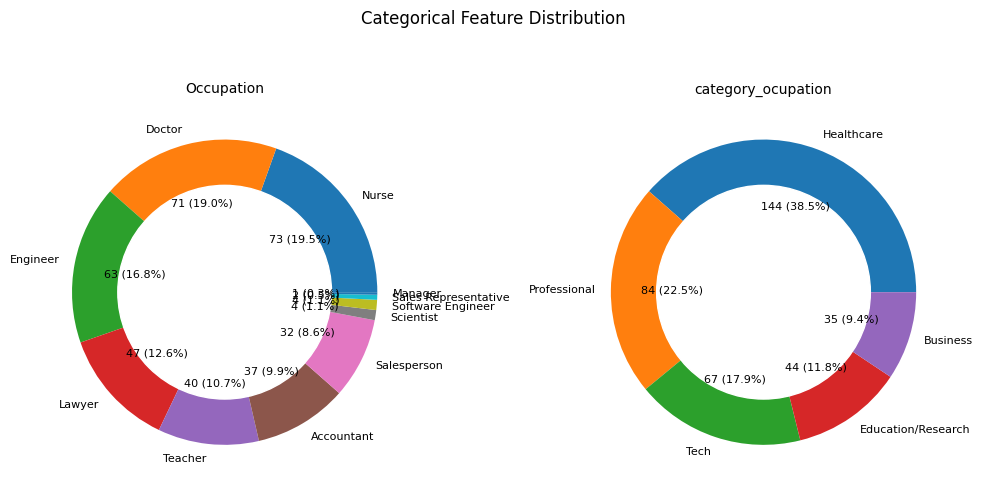

In [127]:
plot_categorical_donut_charts(data[['Occupation', 'category_ocupation']], 1, 2, figsize=(10, 5), c=paleta)

The occupations in the dataset show wide variability, so they were classified into categories based on occupational similarity. The categories used are:

- Healthcare
- Tech
- Education/Research
- Professional
- Business

**Occupation Category Distribution**
- Healthcare (≈38.6%) is the largest group, followed by Professional (≈ 22.5%), Tech (≈18%), Education/Research (≈11.8%), and Business (≈9.4%).
- Insight: Clear predominance of the healthcare sector.
- Interpretation: The population is heavily composed of individuals from the healthcare field, suggesting an environment where health knowledge may be higher, but also where demanding work dynamics may lead to elevated stress levels.

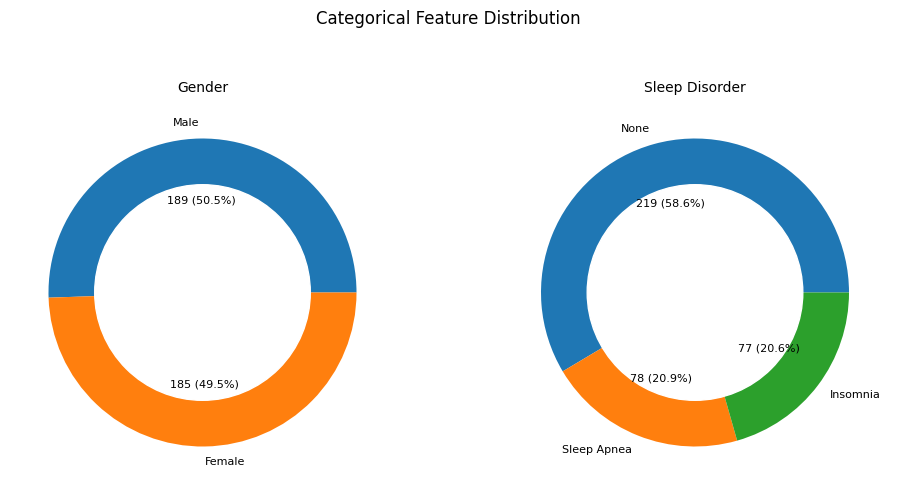

In [128]:
plot_categorical_donut_charts(data[['Gender', 'Sleep Disorder']], 1, 2, figsize=(10, 5), c=paleta)

**Gender**

- Distribution: Male (≈ 50.5%) vs Female (≈ 49.5%).
- Insight: Practically balanced distribution.
- Interpretation: The population has a very uniform gender composition, with no clear predominance of one group over the other.


**Sleep Disorder**

- Distribution: No disorder (≈58.6%), Sleep Apnea (≈20.9%), and Insomnia (≈20.6%).
- Insight: Most of the population does not have sleep disorders, but a considerable proportion (almost 40%) does, almost equally split between apnea and insomnia.
- Interpretation: This indicates that, while the majority sleep without clinical difficulties, there is a significant group with conditions that could affect sleep quality and overall health.

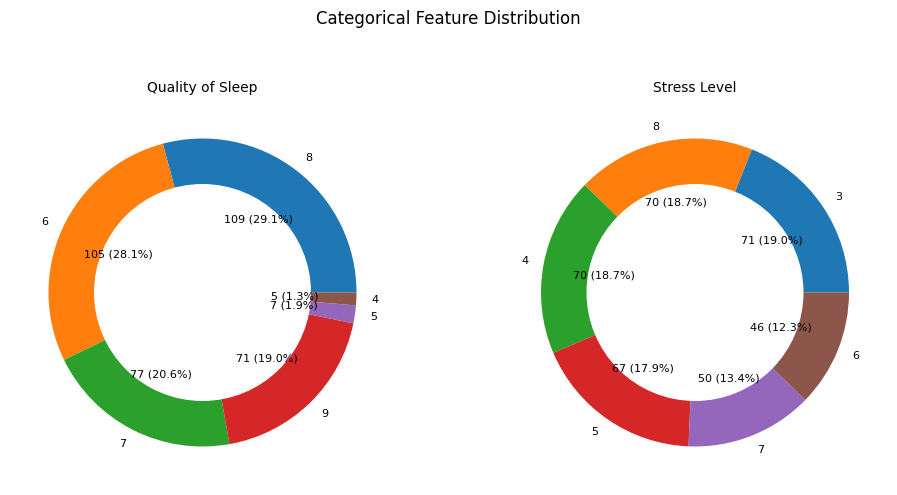

In [129]:
plot_categorical_donut_charts(data[['Quality of Sleep', 'Stress Level']].astype('object'), 1, 2, figsize=(10, 5), c=paleta)

**Quality of Sleep**

- Distribution: Most responses cluster around 6 (≈28%), 8 (≈29%), 9 (19%) and 7 (≈20.6%), with few low values (4–5).
- Insight: Predominance of medium-to-high values.
- Interpretation: The population tends to report relatively good sleep quality, with few cases of very poor sleep.

**Stress Level**

- Distribution: Values range between 3 and 8, with peaks at 3 (≈19%), 8 (≈18.7%), and 4 (≈18.7%).
- Insight: Broad distribution with a slight concentration around medium levels.
- Interpretation: The population exhibits varied stress levels, though intermediate states are more common than extreme ones.

In [130]:
data.columns

Index(['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'BP Category', 'category_ocupation'],
      dtype='object')

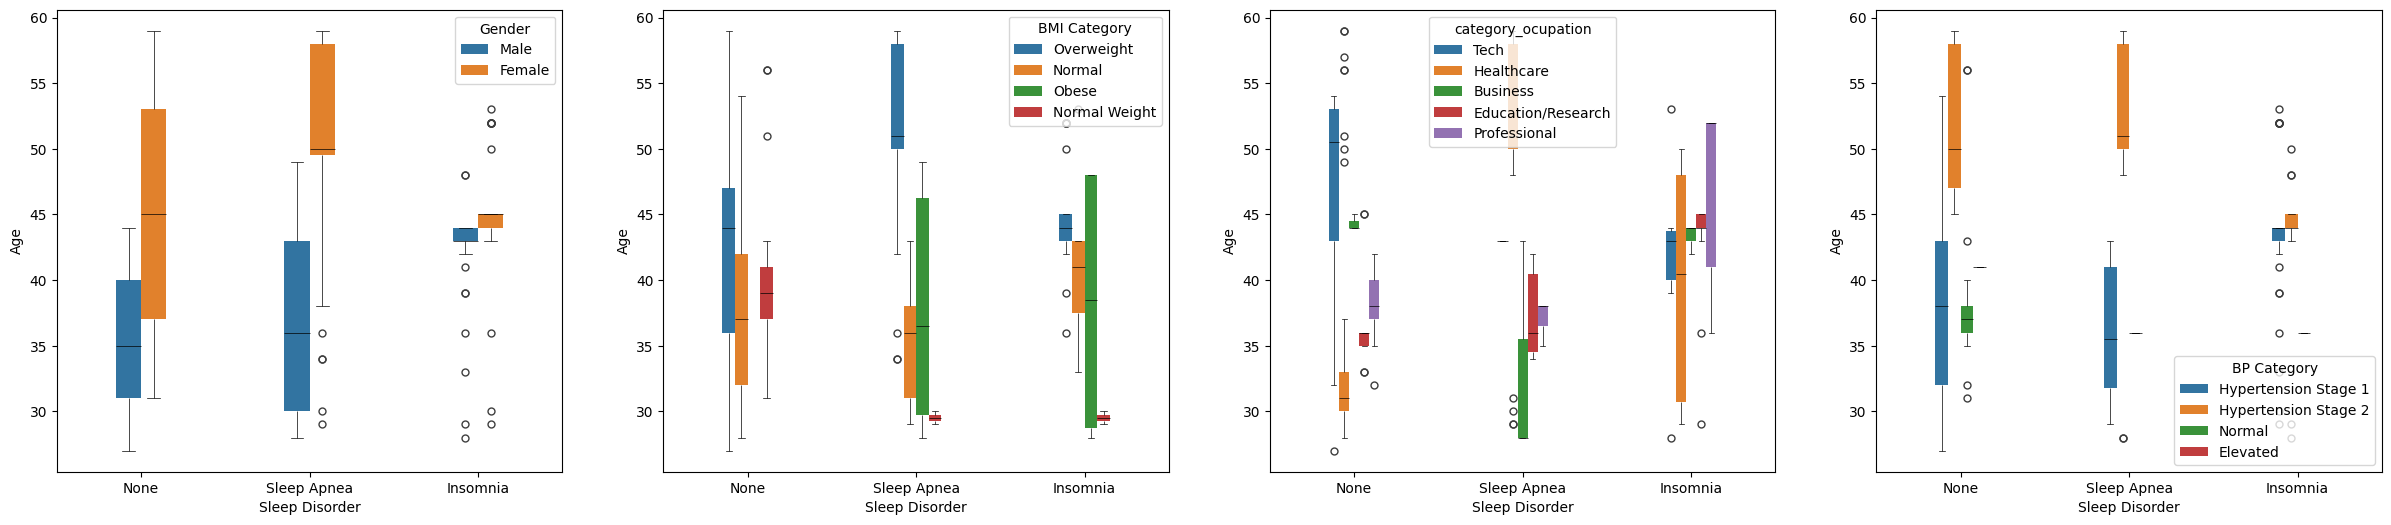

In [131]:

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))

c = ['Gender', 'BMI Category', 'category_ocupation', 'BP Category']

for i in range(4):

  sns.boxplot(
      x=data["Sleep Disorder"],
      y=data["Age"],
      # palette=paleta['smoker'],
      hue=data[c[i]],
      #hue_order=['no', 'yes'],
      boxprops=dict(linewidth=0),
      whiskerprops=dict(color='black', linewidth=0.5),
      capprops=dict(color='black',linewidth=0.5),
      medianprops=dict(color='black',linewidth=0.5),
      width=0.3,
      flierprops = dict(
          marker='o',
          markersize=5,
          linestyle='none'
      ),
      ax=ax[i])




The relationship between three variables is analyzed: age and sleep disorder, with a third variable that may vary across:

**Gender**

- Individuals with sleep apnea tend to be older (higher medians).
- The group without disorders shows greater age dispersion.
- Insomnia appears in intermediate age ranges and exhibits more significant dispersion than the other groups.
- Women tend to be slightly older across all groups. In sleep apnea, the age difference between genders is more pronounced.


**BMI Category**

- Sleep apnea is strongly associated with:
  - Overweight
  - Obesity

- The group without disorders has more individuals within the normal range.
Insomnia shows intermediate patterns.
- Elevated BMI is a key factor in sleep apnea.

**Occupation Category**

- In sleep apnea, there is greater variability (possibly linked to work-related stress).
- In insomnia, there is a higher presence of profiles such as:
  - Education/Research
  - Professionals

- This suggests a relationship between type of work and sleep quality, especially in mentally demanding or cognitively intensive jobs.

**Blood Pressure (BP) Category**
- Sleep apnea is strongly associated with:
  - Hypertension (Stage 1 and 2)
- The group without disorders shows more normal blood pressure levels.
Insomnia presents intermediate values.
- This indicates a link with cardiovascular issues.

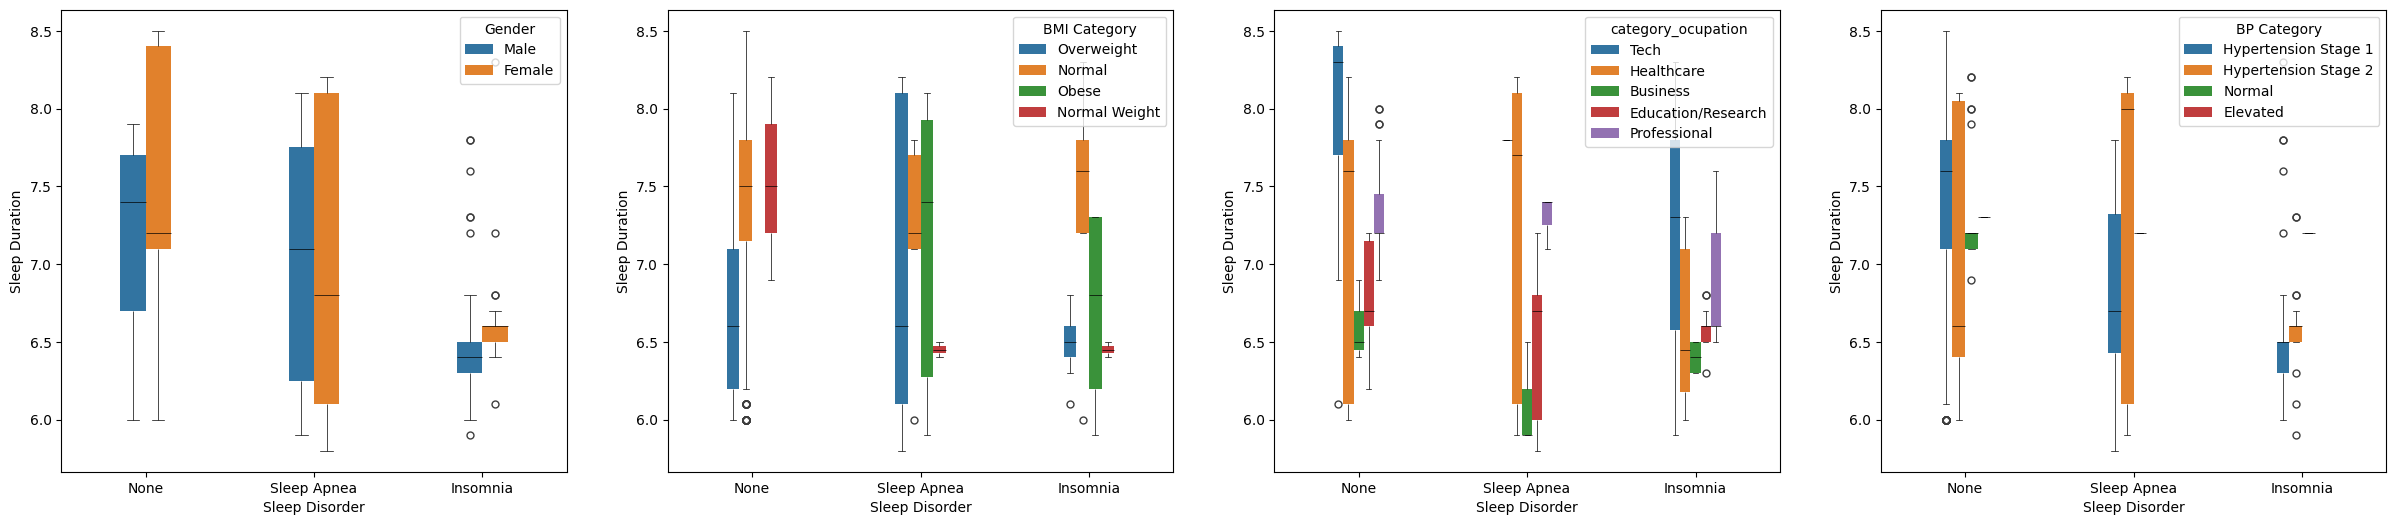

In [132]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))

c = ['Gender', 'BMI Category', 'category_ocupation', 'BP Category']


for i in range(4):

  sns.boxplot(
      x=data["Sleep Disorder"],
      y=data["Sleep Duration"],
      # palette=paleta['smoker'],
      hue=data[c[i]],
      #hue_order=['no', 'yes'],
      boxprops=dict(linewidth=0),
      whiskerprops=dict(color='black', linewidth=0.5),
      capprops=dict(color='black',linewidth=0.5),
      medianprops=dict(color='black',linewidth=0.5),
      width=0.3,
      flierprops = dict(
          marker='o',
          markersize=5,
          linestyle='none'
      ),
      ax=ax[i])


The relationship between three variables is analyzed: sleep duration and sleep disorder, along with a third variable that may vary:

**Gender**

- People without disorders sleep more (≈ 7–8.5 hours)
- People with sleep apnea have more irregular and lower-quality sleep
- People with insomnia have shorter duration (≈ 6–6.5 hours)
- Women tend to sleep slightly more

**BMI Category**

- People without disorders generally sleep between 7 and 8 hours. Those with Normal BMI and Normal Weight sleep a bit more (≈ 7.5–8.4 hours). Those who are Overweight or Obese sleep slightly less, but still within a healthy range
- People with sleep apnea who are Overweight or Obese tend to sleep less (≈ 6.0–7.5 hours)
Those with Normal Weight sleep more, but overall the average decreases. Apnea + high BMI = shorter sleep duration, likely due to interruptions
- People with insomnia have shorter sleep duration across all BMI groups, around 6.2–6.5 hours. The difference between BMI categories is small here; the main limiting factor is insomn

**Occupation Category**

- Without disorder, sleep duration ranges from 7 to 8.5 hours. Occupations in Healthcare and Professional fields sleep slightly more, around 7.5–8 hours. Tech and Business occupations show more variation in duration, but generally around 7–7.5 hours
- With sleep apnea, the average duration is lower (6–7.5 hours). Occupations in Business and Education/Research show shorter sleep duration, reflecting possible work stress or interruptions. Healthcare and Professional groups sleep a bit more, but less than those without disorders
- With insomnia, sleep duration is shorter and more uniform, around 6.3–6.8 hours across all categories. Differences between occupations are less pronounced, indicating that insomnia affects sleep duration regardless of job


Blood Pressure Category

- Without disorder, duration ranges from 7 to 8.5 hours. People with normal or elevated blood pressure sleep more. Stage 1 and 2 hypertension show a slight tendency toward shorter sleep (≈ 7 hours)
- With sleep apnea, people with hypertension (Stage 1 and 2) have shorter sleep duration, around 6–7 hours. Hypertension is clearly associated with shorter duration and poorer sleep quality
- With insomnia, sleep duration remains consistently low (~6.3–6.7 hours) across all blood pressure categories. Differences by blood pressure category are minimal compared to the effect of insomnia

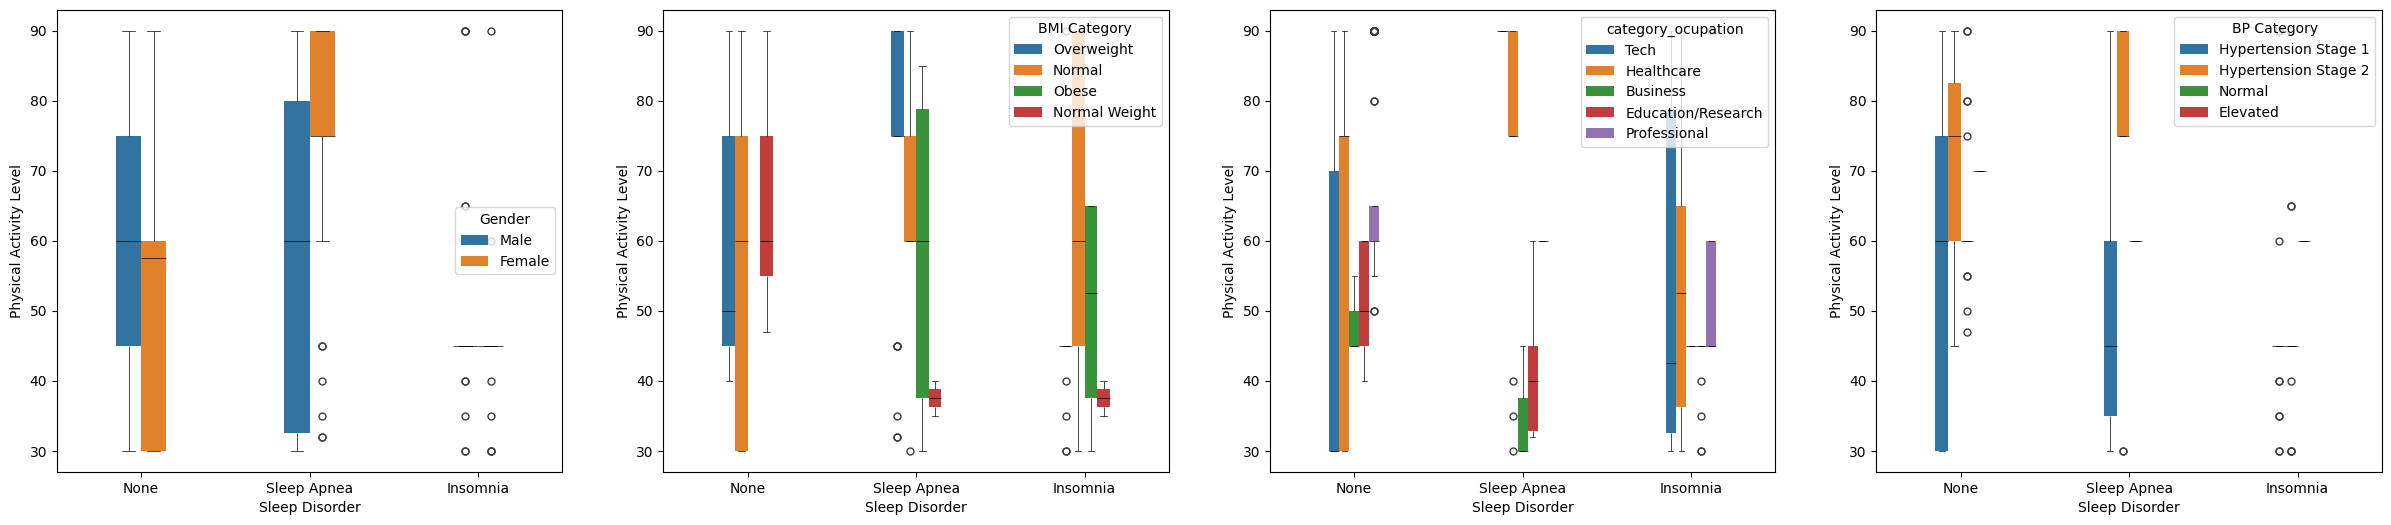

In [133]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))

c = ['Gender', 'BMI Category', 'category_ocupation', 'BP Category']

for i in range(4):

  sns.boxplot(
      x=data["Sleep Disorder"],
      y=data["Physical Activity Level"],
      # palette=paleta['smoker'],
      hue=data[c[i]],
      #hue_order=['no', 'yes'],
      boxprops=dict(linewidth=0),
      whiskerprops=dict(color='black', linewidth=0.5),
      capprops=dict(color='black',linewidth=0.5),
      medianprops=dict(color='black',linewidth=0.5),
      width=0.3,
      flierprops = dict(
          marker='o',
          markersize=5,
          linestyle='none'
      ),
      ax=ax[i])


**Gender**

- Among people without sleep disorders, both Male and Female groups show moderate to high physical activity levels. However, males tend to display a wider range of values, while females are more concentrated in mid-level activity ranges.

- For individuals with sleep apnea, both Male and Female categories reach high activity levels, but males again show greater variability, with values ranging from low to very high. Females tend to maintain more consistent, relatively high activity levels.

- In the insomnia group, both Male and Female individuals generally show lower physical activity levels, with noticeable dispersion. This suggests less stable or less consistent activity patterns across both genders.


**BMI Category**

- Within the group without sleep disorders, individuals in the Normal Weight and Normal categories tend to have moderate to high activity levels. Those in the Overweight category also show relatively good activity levels.

- Among individuals with sleep apnea, the Overweight and Obese categories exhibit strong variability. Some individuals in these groups reach very high activity levels, while others fall into much lower ranges, indicating inconsistency.

- For individuals with insomnia, activity levels across Normal Weight, Normal, Overweight, and Obese categories tend to cluster in moderate to lower ranges, generally below those observed in the group without sleep disorders.


**category_occupation**

- In the group without sleep disorders, individuals working in Tech and Healthcare occupations tend to show higher physical activity levels. Those in Business, Education/Research, and Professional categories typically fall into moderate activity ranges.

- Among individuals with sleep apnea, the Healthcare category continues to show relatively high activity levels. In contrast, Business and Education/Research categories tend to have lower activity levels, while Tech and Professional show mixed results with noticeable variability.

- For individuals with insomnia, all occupation categories (Tech, Healthcare, Business, Education/Research, Professional) show high variability, but overall activity tends to be lower, especially in more sedentary roles like Business and Education/Research.


**BP_Category**

- Among individuals without sleep disorders, those in the Normal and Elevated blood pressure categories tend to have moderate to high activity levels. The Hypertension Stage 1 and Stage 2 categories show slightly lower but still moderate activity.

- For individuals with sleep apnea, activity levels tend to decrease as blood pressure increases across Normal, Elevated, Hypertension Stage 1, and Hypertension Stage 2 categories. Variability is especially noticeable in Hypertension Stage 1.

- In the insomnia group, individuals across all categories (Normal, Elevated, Hypertension Stage 1, Hypertension Stage 2) tend to show lower activity levels overall, with the lowest levels often appearing in the higher hypertension stages.

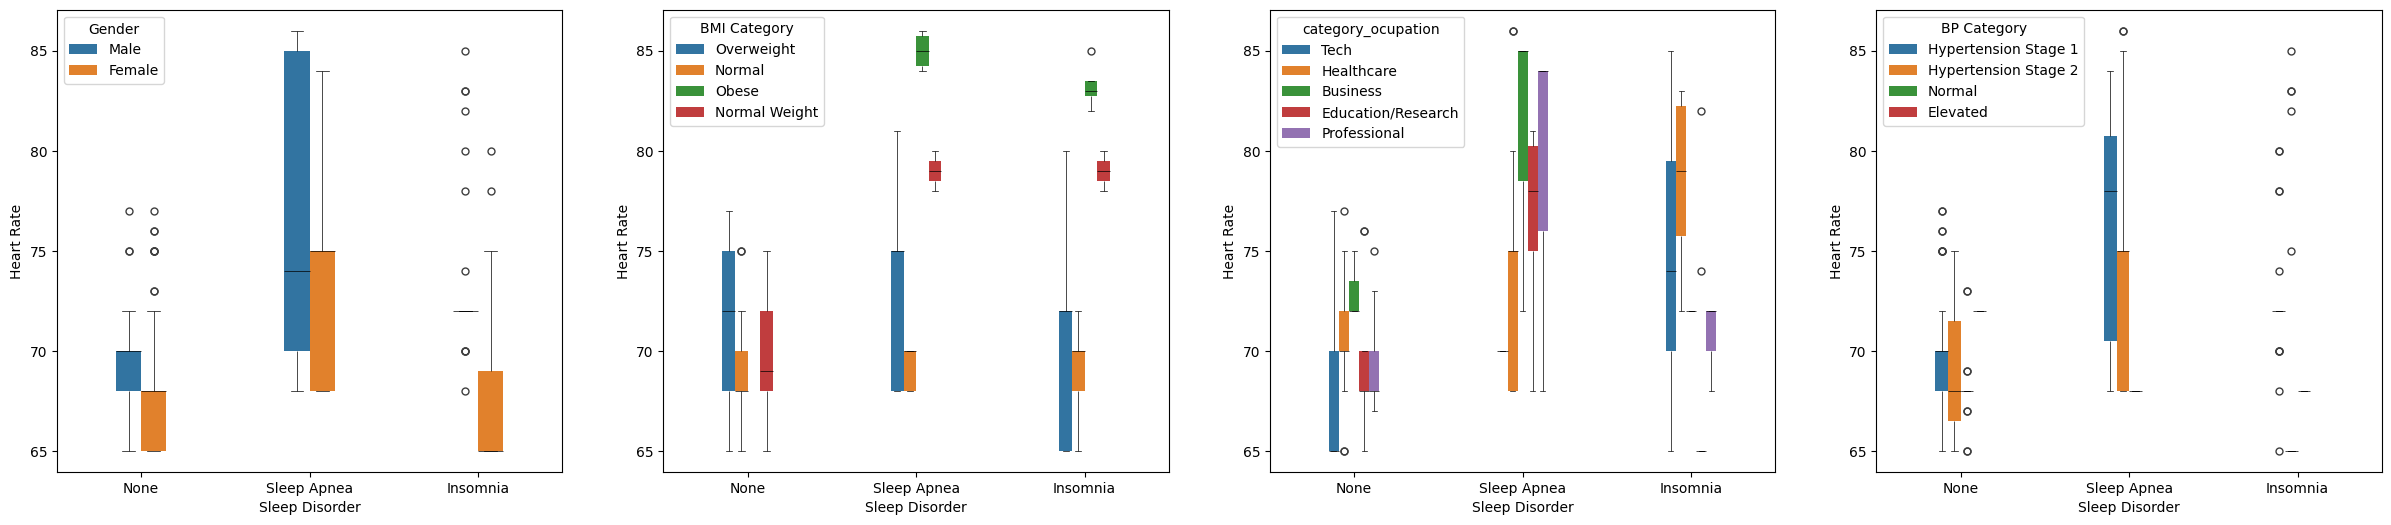

In [134]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))

c = ['Gender', 'BMI Category', 'category_ocupation', 'BP Category']

for i in range(4):

  sns.boxplot(
      x=data["Sleep Disorder"],
      y=data["Heart Rate"],
      # palette=paleta['smoker'],
      hue=data[c[i]],
      #hue_order=['no', 'yes'],
      boxprops=dict(linewidth=0),
      whiskerprops=dict(color='black', linewidth=0.5),
      capprops=dict(color='black',linewidth=0.5),
      medianprops=dict(color='black',linewidth=0.5),
      width=0.3,
      flierprops = dict(
          marker='o',
          markersize=5,
          linestyle='none'
      ),
      ax=ax[i])


**Gender**

- Among individuals without sleep disorders, both Male and Female groups show relatively stable heart rate values, generally concentrated in the mid-to-high 60s and low 70s. Males tend to have slightly higher variability, with some higher values.

- For individuals with sleep apnea, both Male and Female categories show an increase in heart rate levels. Males, in particular, display higher maximum values and greater dispersion, while females remain slightly more concentrated but still elevated compared to the “None” group.

- In the insomnia group, both Male and Female individuals show moderate heart rate levels, generally lower than those with sleep apnea but slightly more variable than the “None” group. Males again show more spread, including some higher outliers.


**BMI Category**

- Among individuals without sleep disorders, all BMI categories (Normal Weight, Normal, Overweight, Obese) show relatively similar heart rate ranges, mostly between mid-60s and low-70s, with minor variability.

- For individuals with sleep apnea, clear differences appear. The Obese category shows the highest heart rate levels (around mid-80s), followed by Normal Weight (around high-70s). Overweight and Normal categories remain lower but still elevated compared to the “None” group.

- In the insomnia group, heart rate levels are more moderate across all categories (Normal Weight, Normal, Overweight, Obese), typically ranging from mid-60s to low-70s. However, the Obese group still shows relatively higher values compared to others.

**category_occupation**

- Among individuals without sleep disorders, all occupation categories (Tech, Healthcare, Business, Education/Research, Professional) show similar heart rate levels, generally between mid-60s and low-70s, with slight variability. Business and Healthcare show slightly higher medians.

- For individuals with sleep apnea, heart rate increases across all occupations. Business shows the highest levels (reaching mid-80s), followed by Professional and Education/Research. Tech and Healthcare are slightly lower but still elevated compared to the “None” group.

- In the insomnia group, heart rate levels are more moderate. Healthcare and Tech show relatively higher values (mid to high 70s), while Professional and Education/Research tend to be lower (around 70). Business shows mixed values with noticeable variability.

**BP_Category**

- Among individuals without sleep disorders, heart rate remains relatively stable across all categories (Normal, Elevated, Hypertension Stage 1, Hypertension Stage 2), generally ranging from mid-60s to low-70s.

- For individuals with sleep apnea, heart rate increases notably across all blood pressure categories. Hypertension Stage 1 shows the highest values (approaching 80+), followed by Hypertension Stage 2. Normal and Elevated are slightly lower but still higher than in the “None” group.

- In the insomnia group, heart rate is more moderate across all categories (Normal, Elevated, Hypertension Stage 1, Hypertension Stage 2), typically between mid-60s and low-70s, although some higher outliers appear in the hypertension groups.


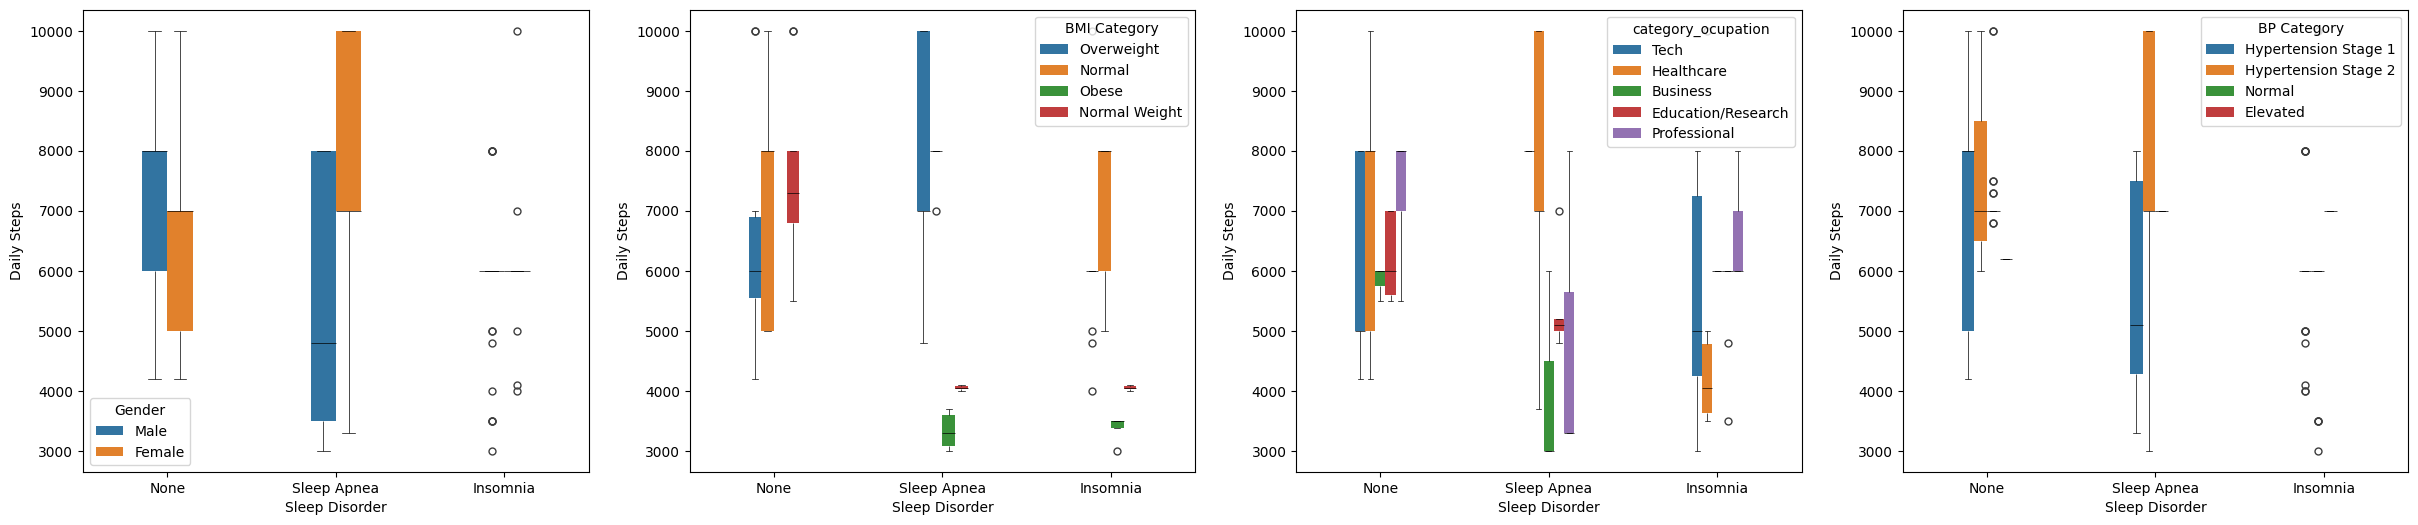

In [135]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))

c = ['Gender', 'BMI Category', 'category_ocupation', 'BP Category']

for i in range(4):

  sns.boxplot(
      x=data["Sleep Disorder"],
      y=data["Daily Steps"],
      # palette=paleta['smoker'],
      hue=data[c[i]],
      #hue_order=['no', 'yes'],
      boxprops=dict(linewidth=0),
      whiskerprops=dict(color='black', linewidth=0.5),
      capprops=dict(color='black',linewidth=0.5),
      medianprops=dict(color='black',linewidth=0.5),
      width=0.3,
      flierprops = dict(
          marker='o',
          markersize=5,
          linestyle='none'
      ),
      ax=ax[i])

**Gender**

- Among individuals without sleep disorders, both Male and Female groups show relatively high daily step counts. Males tend to range between about 6,000 and 8,000 steps, while females are slightly lower on average, typically between 5,000 and 7,000, although both groups can reach up to 10,000 steps.

- For individuals with sleep apnea, variability increases significantly. Females often reach the highest step counts (around 7,000 to 10,000), while males show a very wide range, from low values (around 3,000–4,000) to high values (up to 8,000). This indicates inconsistent activity patterns, especially among males.

- In the insomnia group, both Male and Female individuals generally show lower daily steps. Most values fall between 3,000 and 6,000, although there are some higher outliers. Overall, this group reflects reduced and less consistent physical activity.

**BMI Category**

- Among individuals without sleep disorders, the Normal and Normal Weight categories tend to have higher daily step counts (around 7,000–8,000 or more). The Overweight category shows moderate levels (around 5,500–7,000), while the Obese category is slightly lower but still within a similar range.

- For individuals with sleep apnea, strong differences emerge. The Overweight category reaches very high values (up to 10,000 steps), while the Normal category also shows high activity (around 7,000–8,000). In contrast, the Obese category drops significantly (around 3,000–3,500), and Normal Weight remains moderate (around 4,000).

- In the insomnia group, daily steps are generally lower across all categories. The Normal category still shows relatively higher values (around 6,000–8,000), but Overweight, Obese, and Normal Weight tend to cluster at lower levels (around 3,000–5,000), indicating reduced activity.

**category_occupation**

- Among individuals without sleep disorders, Tech, Healthcare, and Professional occupations tend to have higher daily steps (around 7,000–8,000). Business and Education/Research show slightly lower values (around 5,500–7,000), suggesting more sedentary routines.

- For individuals with sleep apnea, Healthcare shows the highest step counts (up to 10,000), followed by Tech (around 8,000). In contrast, Business, Education/Research, and Professional categories show much lower values, often between 3,000 and 6,000, indicating reduced activity in these roles.

- In the insomnia group, daily steps are generally lower across all occupations. Professional and Tech show moderate values (around 6,000–7,000), while Healthcare, Business, and Education/Research tend to fall between 3,500 and 5,000, reflecting lower activity levels overall.

**BP_Category**

- Among individuals without sleep disorders, those in Normal, Elevated, Hypertension Stage 1, and Hypertension Stage 2 categories show relatively high daily step counts, often between 6,000 and 8,500 steps, with some reaching up to 10,000.

- For individuals with sleep apnea, variability increases notably. Hypertension Stage 2 shows the highest values (up to 10,000), while Hypertension Stage 1 displays a wide range (from about 3,000 to 8,000). Normal and Elevated categories tend to fall in moderate ranges (around 4,500–7,000).

- In the insomnia group, daily steps are generally lower across all categories. Most values fall between 3,000 and 6,000, although some individuals in Hypertension Stage 2 and Stage 1 reach higher values. Overall, this group reflects reduced physical activity regardless of blood pressure level.

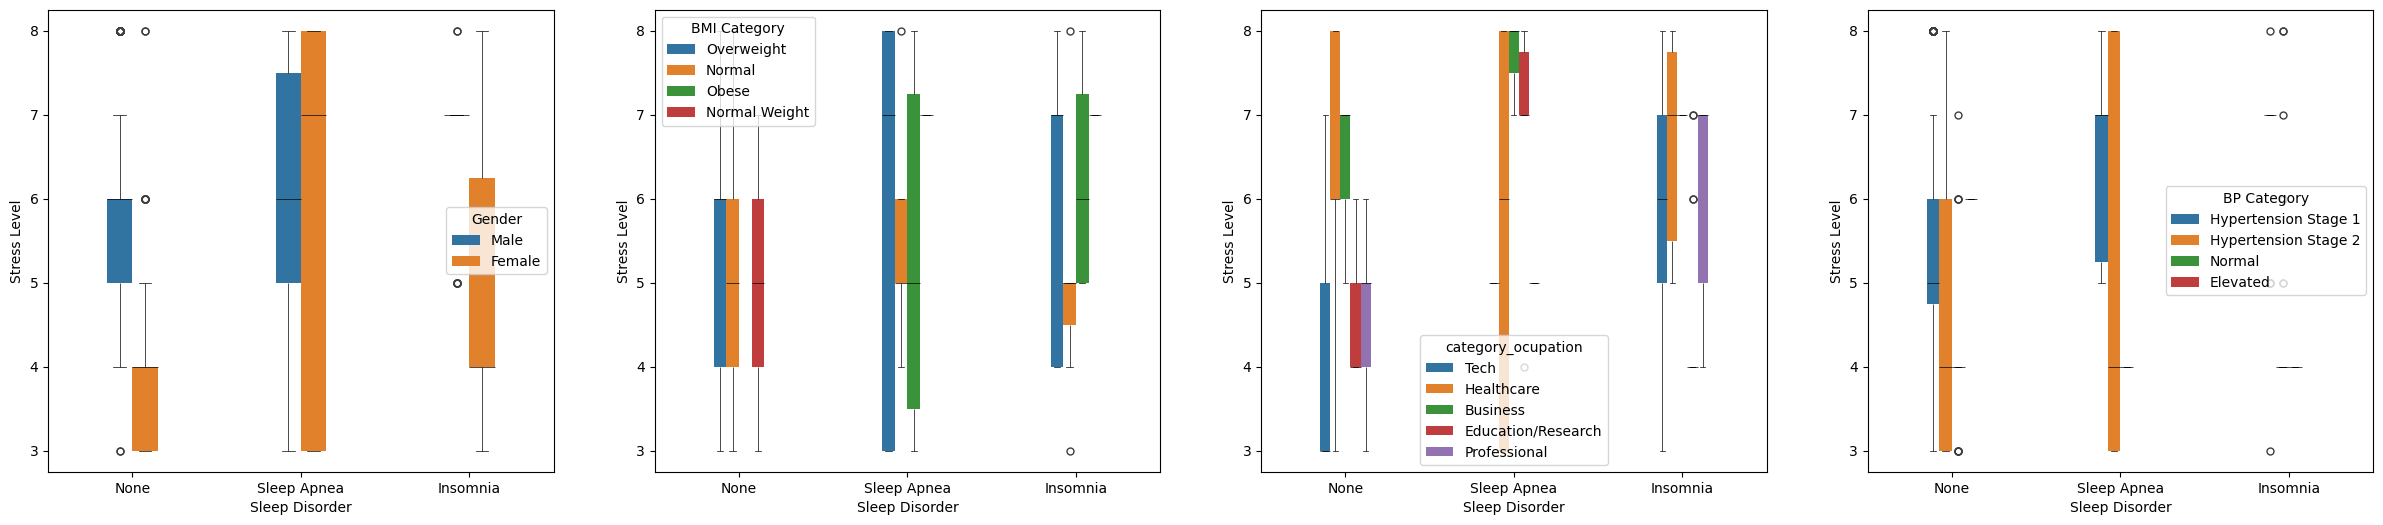

In [136]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))

c = ['Gender', 'BMI Category', 'category_ocupation', 'BP Category']

for i in range(4):

  sns.boxplot(
      x=data["Sleep Disorder"],
      y=data["Stress Level"].astype('object'),
      # palette=paleta['smoker'],
      hue=data[c[i]],
      #hue_order=['no', 'yes'],
      boxprops=dict(linewidth=0),
      whiskerprops=dict(color='black', linewidth=0.5),
      capprops=dict(color='black',linewidth=0.5),
      medianprops=dict(color='black',linewidth=0.5),
      width=0.3,
      flierprops = dict(
          marker='o',
          markersize=5,
          linestyle='none'
      ),
      ax=ax[i])

**Gender**

- Among individuals without sleep disorders, stress levels for males tend to concentrate between 5 and 6, while females show slightly lower values, often between 3 and 4, indicating a moderate gender gap in perceived stress.

- In the sleep apnea group, stress levels increase notably for both genders. Males exhibit a wider spread (approximately 5 to 8), while females show even greater variability, ranging from 3 to 8, suggesting inconsistent stress responses within this subgroup.

- For individuals with insomnia, stress levels remain elevated. Females tend to cluster between 4 and 6, while males maintain slightly higher values, reaching up to 7–8. Overall, insomnia is associated with sustained higher stress levels across genders.

**BMI Category**

- For individuals without sleep disorders, stress levels are relatively stable across BMI categories, generally ranging between 4 and 6, indicating limited differentiation by body composition.

- In the sleep apnea group, variability increases significantly:

  - Overweight individuals show the widest dispersion (3 to 8)
  - Obese individuals trend toward higher stress levels (5 to 7+)
  - Normal BMI individuals remain in moderate ranges (5 to 6)

- For the insomnia group, stress levels remain moderately high across all BMI categories, typically between 4 and 7, with obese individuals again showing a tendency toward higher stress.

**category_occupation**
- Among individuals without sleep disorders, stress levels vary by occupation:

  - Healthcare shows higher stress (6–8)
  - Business and Education/Research remain moderate (5–7)
  - Tech shows lower values (3–5)

 In the sleep apnea group, stress increases across all occupations:

  - Healthcare and Education/Research reach the highest levels (7–8)
  - Tech remains lower but more variable
  - Overall dispersion is significantly higher

- For insomnia, stress levels remain elevated across occupations, generally between 5 and 7, with less differentiation compared to other groups, suggesting that insomnia may dominate occupational effects.


**BP_Category**

- Among individuals without sleep disorders, stress levels are moderate:

  - Most values fall between 4 and 6
  - Slight increases observed in Hypertension Stage 1 and 2

- In the sleep apnea group, stress levels increase and spread widens:

 - Hypertension Stage 2 shows the highest variability (3 to 8)
 - Other categories cluster between 5 and 7

- For insomnia, stress levels remain elevated but more concentrated:

 - Most values fall between 4 and 7
 - Less variability compared to sleep apnea

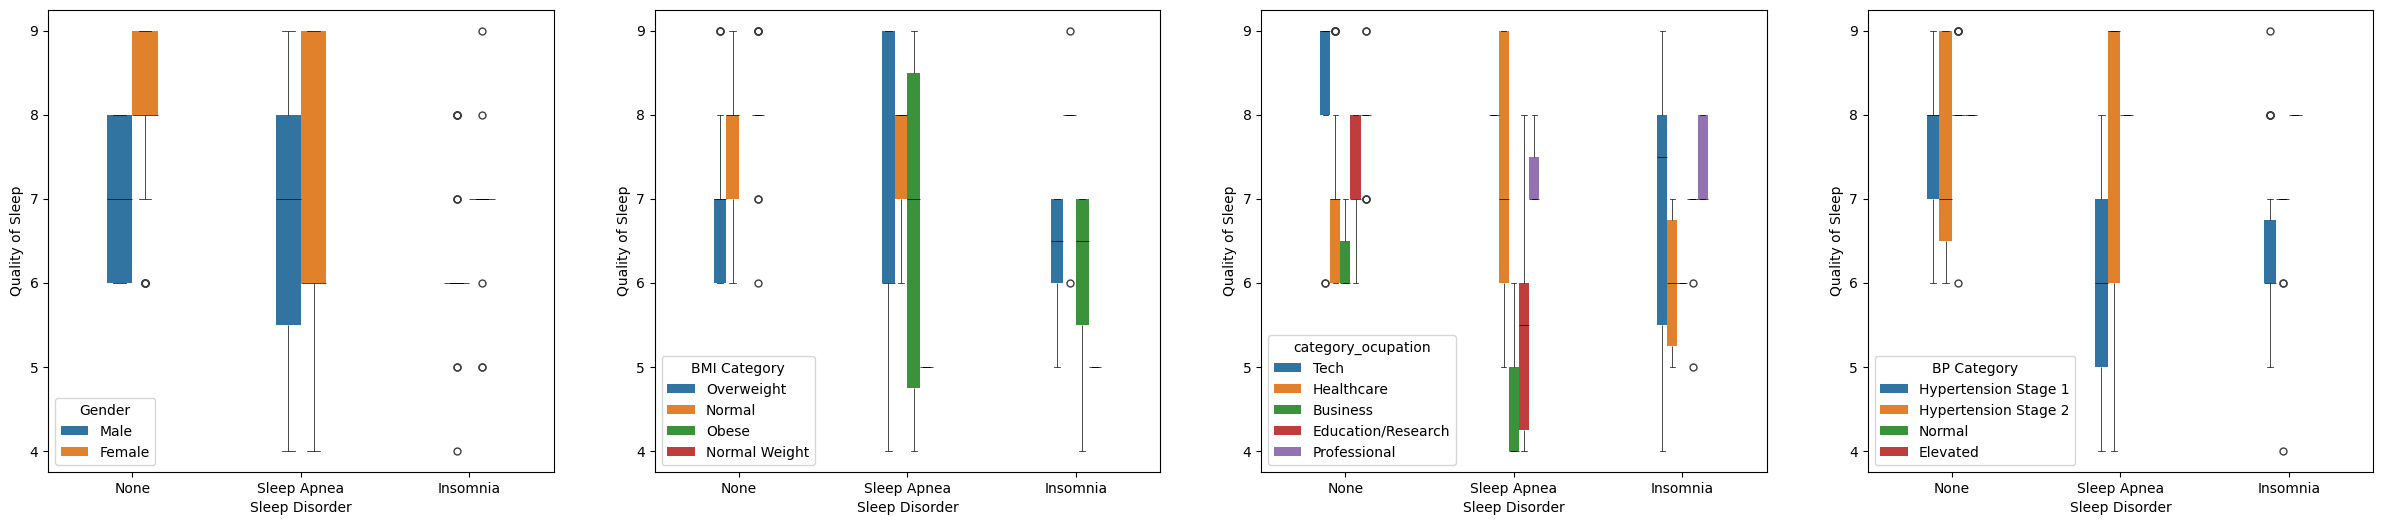

In [137]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))

c = ['Gender', 'BMI Category', 'category_ocupation', 'BP Category']

for i in range(4):

  sns.boxplot(
      x=data["Sleep Disorder"],
      y=data["Quality of Sleep"].astype('object'),
      # palette=paleta['smoker'],
      hue=data[c[i]],
      #hue_order=['no', 'yes'],
      boxprops=dict(linewidth=0),
      whiskerprops=dict(color='black', linewidth=0.5),
      capprops=dict(color='black',linewidth=0.5),
      medianprops=dict(color='black',linewidth=0.5),
      width=0.3,
      flierprops = dict(
          marker='o',
          markersize=5,
          linestyle='none'
      ),
      ax=ax[i])

**Gender**

- Among individuals without sleep disorders, sleep quality is generally high. Males typically range between 6 and 8, while females tend to show slightly higher values, often reaching 8 to 9, indicating better perceived sleep quality in this group.

- In the sleep apnea group, variability increases considerably. Males show a wide distribution (5 to 8), while females range even more broadly (4 to 9), suggesting inconsistent sleep quality across individuals.

- For those with insomnia, sleep quality declines overall. Both genders exhibit lower and more dispersed values, generally between 4 and 7, although some outliers reach higher values. This indicates a consistent degradation in sleep quality regardless of gender.


**BMI Category**

- For individuals without sleep disorders, sleep quality remains relatively stable across BMI categories, mostly between 6 and 8, with occasional higher values.

- In the sleep apnea group, dispersion increases notably:

  - Overweight individuals show wide variability (6 to 9)
  - Obese individuals tend toward lower values (~4 to 7)
  - Normal BMI individuals remain relatively higher (7 to 8)

- For the insomnia group, sleep quality is generally lower across all BMI categories, typically between 5 and 7, with obese individuals again showing slightly lower trends.


**Occupation**
- Among individuals without sleep disorders, sleep quality varies moderately:
    - Tech shows higher values (8–9)
    - Healthcare and Business remain around 6–7
    - Education/Research slightly higher (7–8)

- In the sleep apnea group, sleep quality becomes more inconsistent:

    - Healthcare shows the widest spread (6 to 9)
    - Business drops to lower values (4–5)
    - Education/Research also shows lower ranges (~4–6)
    - Greater dispersion overall suggests occupation-specific stress or lifestyle effects
- For insomnia, sleep quality remains moderately low across all occupations (5 to 8), with reduced variability compared to sleep apnea, indicating a more uniform impact.

**BP_Category**
- Among individuals without sleep disorders, sleep quality is generally high:
  - Most values range between 7 and 9
  - Slight variations across BP categories
- In the sleep apnea group, variability increases:

  - Hypertension Stage 2 shows the widest range (4 to 9)
  - Other categories cluster between 5 and 8

- For insomnia, sleep quality declines:

  - Most values fall between 5 and 7
  - Less dispersion compared to sleep apnea

In [138]:
c = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate', 'Daily Steps']
c

['Age',
 'Sleep Duration',
 'Physical Activity Level',
 'Heart Rate',
 'Daily Steps']

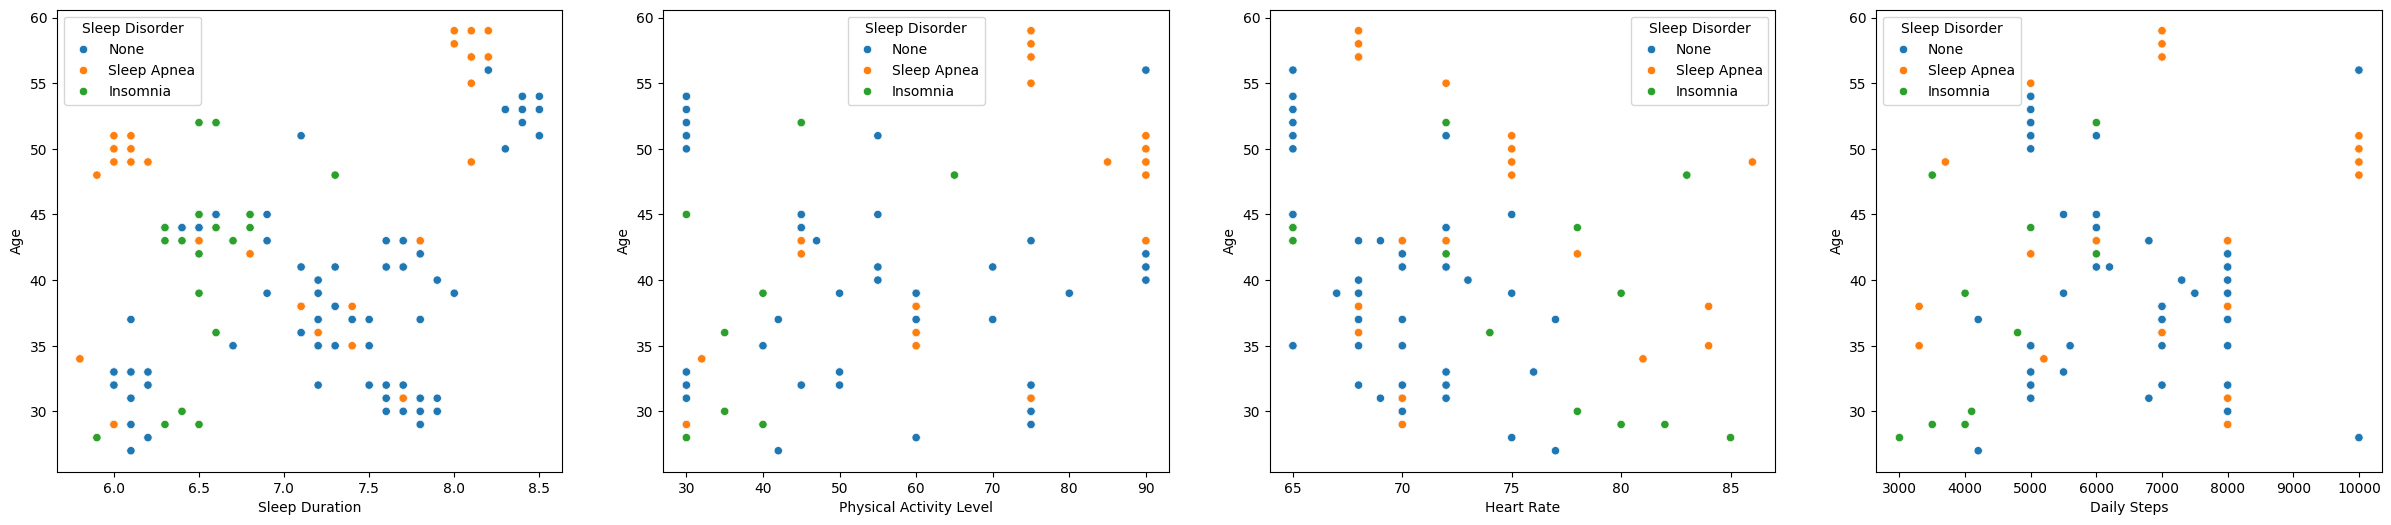

In [139]:

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))
c = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate', 'Daily Steps']
c.remove("Age")
for i in range(4):
  sns.scatterplot(
    data=data,
    y='Age',
    x=c[i],
    hue='Sleep Disorder',
    ax=ax[i]
)

In general, no clear or linear relationship is observed between age and the analyzed variables (Sleep Duration, Physical Activity Level, Heart Rate, and Daily Steps). There is high dispersion in all cases, indicating that age alone does not explain the behavior of these variables.


* **Sleep Duration:** does not clearly change with age; variability depends more on the type of disorder.
* **Physical Activity Level:** high dispersion across all ages; sleep apnea shows the widest ranges.
* **Heart Rate:** no trend with age; values are similarly distributed across all groups.
* **Daily Steps:** highly dispersed behavior; again, sleep apnea shows greater variability.


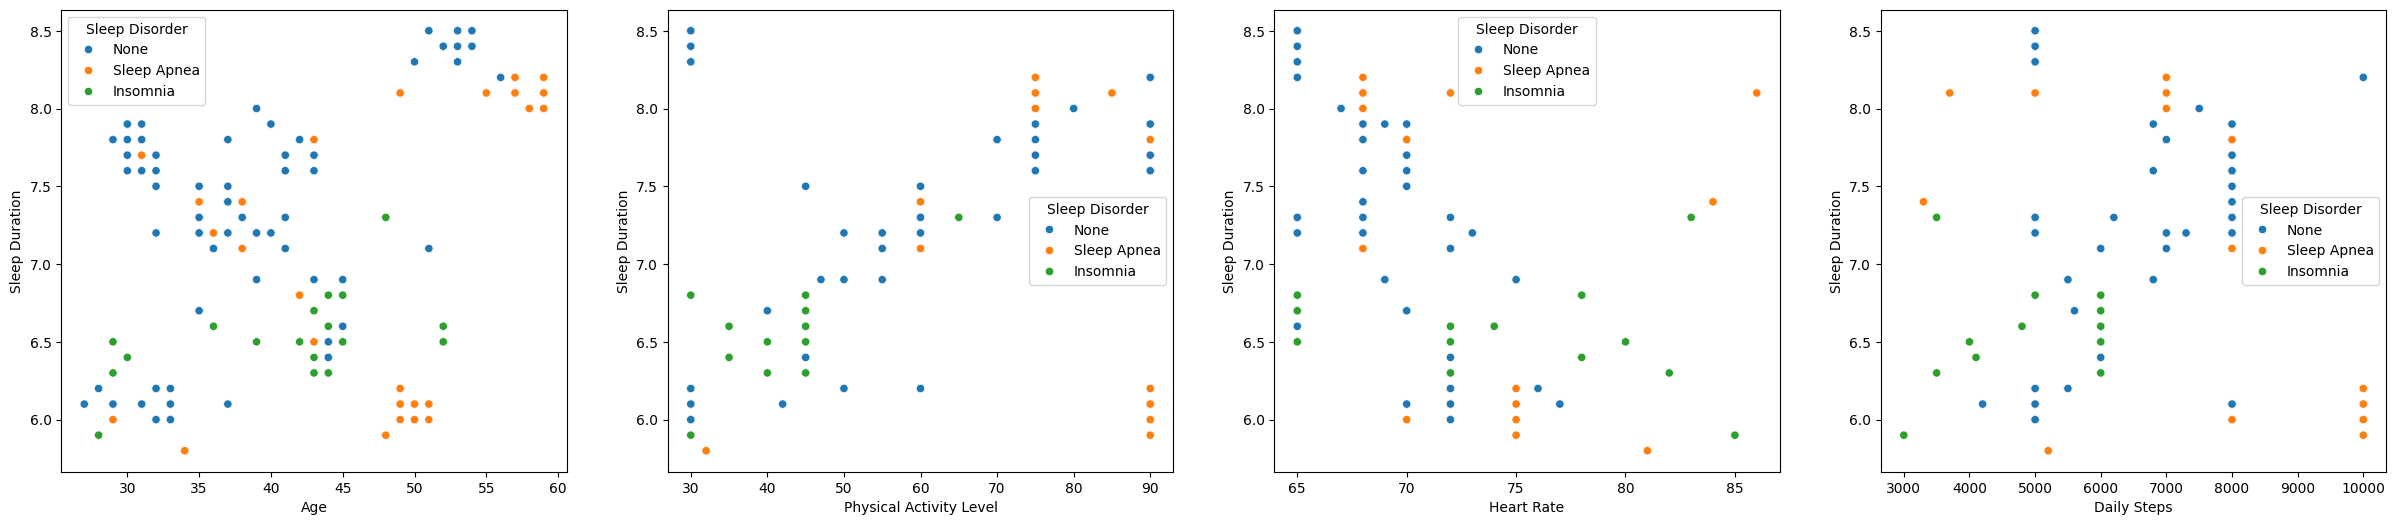

In [140]:

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))
c = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate', 'Daily Steps']
c.remove("Sleep Duration")
for i in range(4):
  sns.scatterplot(
    data=data,
    y='Sleep Duration',
    x=c[i],
    hue='Sleep Disorder',
    ax=ax[i]
)

**Age**

* In general, no clear or linear relationship is observed between Sleep Duration and age.

**Physical Activity Level**

* Higher activity levels are associated with longer sleep duration, suggesting that physical activity may be linked to better sleep quality or quantity.
* Individuals without disorders show a fairly consistent upward trend.
* Sleep apnea cases partially follow this trend, although with greater variability.
* Insomnia is concentrated at low to moderate activity levels and shorter sleep duration.

**Heart Rate**

* There is no strong correlation, but there are indications that higher heart rates may be associated with shorter sleep duration.
* Higher heart rates (75–85) tend to be linked to less sleep, especially in insomnia cases.
* Individuals without disorders show a wide distribution, with several cases in mid-range heart rates (68–75) and moderate-to-high sleep duration.
* Sleep apnea appears in intermediate ranges, without a clear trend.

**Daily Steps**

* There is a positive trend: more daily steps are associated with longer sleep duration.
* Individuals without disorders dominate the higher ranges of steps (7000–9000) and sleep (7–8 hours).
* Insomnia is concentrated at lower step counts and shorter sleep duration.
* Sleep apnea shows greater dispersion, including some cases with many steps but low sleep duration.


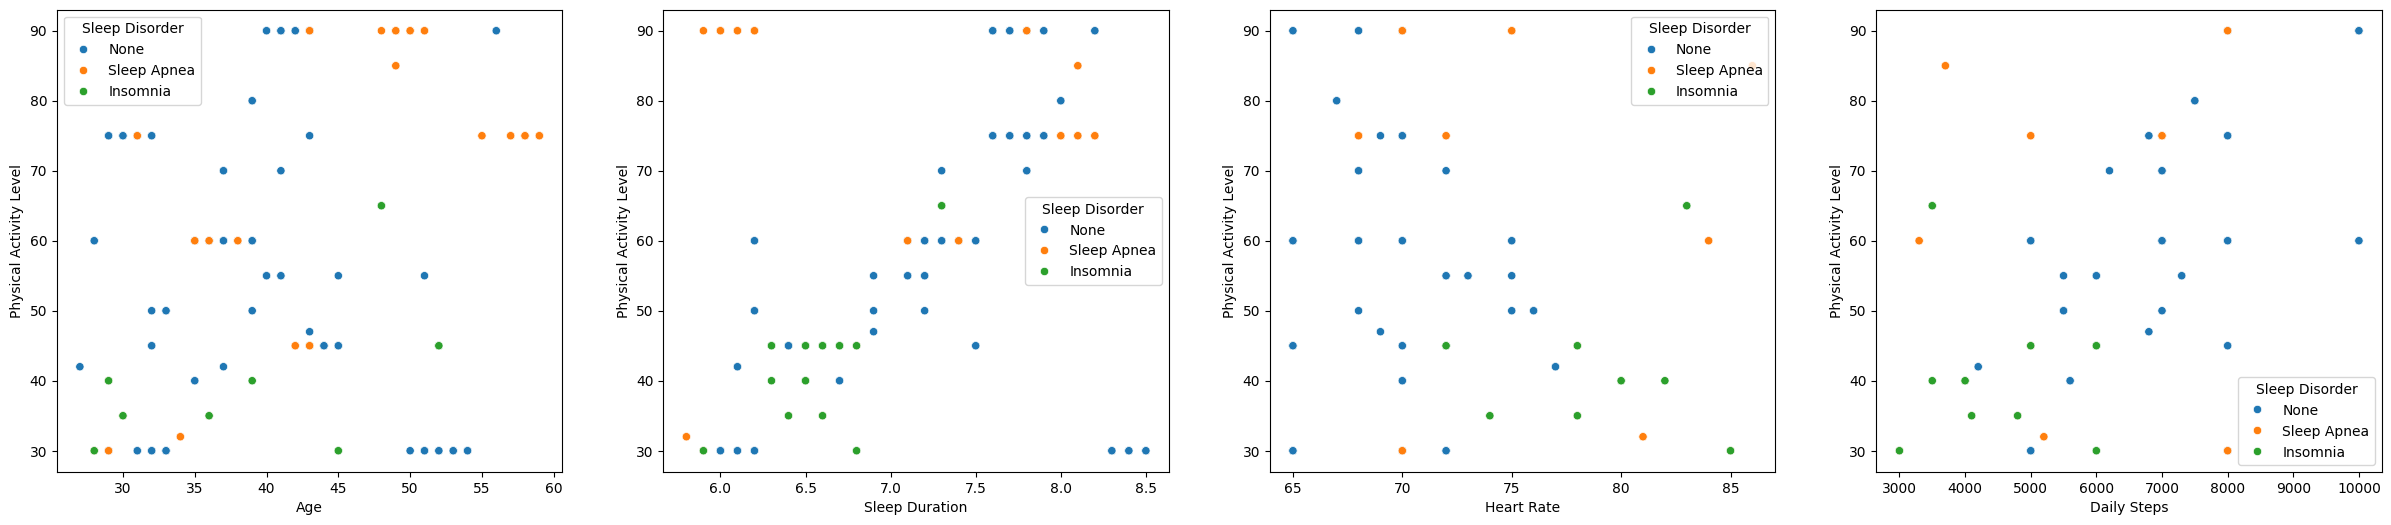

In [141]:

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))
c = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate', 'Daily Steps']
c.remove("Physical Activity Level")
for i in range(4):
  sns.scatterplot(
    data=data,
    y='Physical Activity Level',
    x=c[i],
    hue='Sleep Disorder',
    ax=ax[i]
)

**Age**

* In general, no clear or linear relationship is observed between Sleep Duration and age.

**Sleep Duration**

* Longer sleep duration is associated with higher levels of physical activity.
* No disorder: clearly follows an upward trend.
* Insomnia: concentrated in low sleep and low activity levels.
* Sleep apnea: more dispersed, but many cases appear at high activity levels and medium–high sleep duration.

**Heart Rate**

* There is a weak negative correlation.
* Insomnia: more frequent at low activity levels and medium–high heart rates.
* No disorder: wide distribution across all ranges.
* Sleep apnea: quite dispersed, with no clear pattern.

**Daily Steps**

* There is a very clear positive correlation: more steps → higher physical activity level.
* No disorder: dominates higher ranges of steps and activity.
* Insomnia: concentrated at low step counts and low activity levels.
* Sleep apnea: appears across the full range, with several high-value cases.


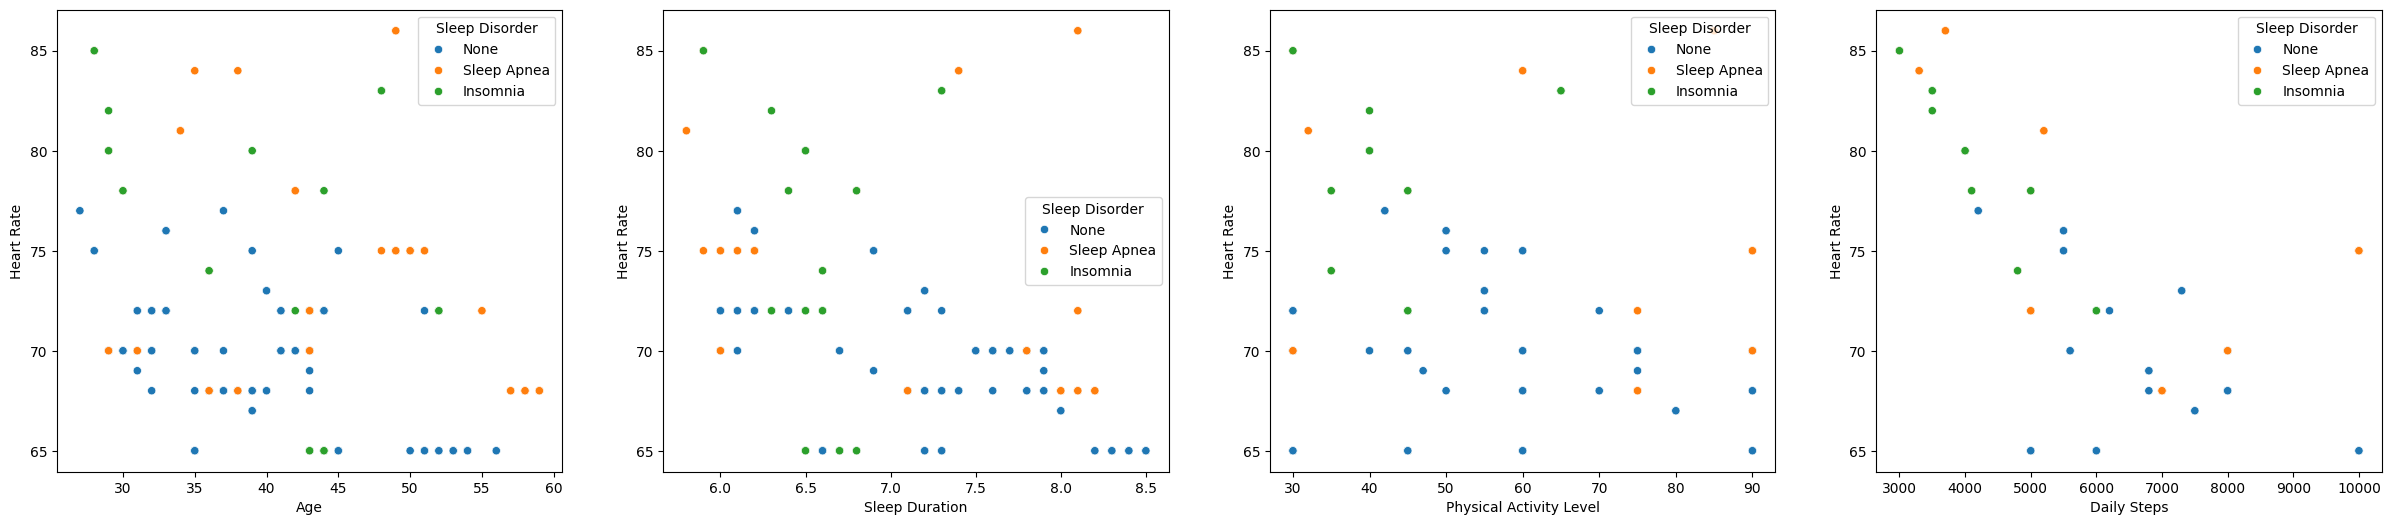

In [142]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30, 6))
c = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate', 'Daily Steps']
c.remove("Heart Rate")
for i in range(4):
  sns.scatterplot(
    data=data,
    y='Heart Rate',
    x=c[i],
    hue='Sleep Disorder',
    ax=ax[i]
)

**Age**

- In general, no clear or linear relationship is observed between Sleep Duration and age.

**Sleep Duration**

- Individuals without disorders sleep more hours and have lower heart rates. As sleep duration decreases, heart rate increases.
- The insomnia group is concentrated in low sleep duration and high heart rate, which clearly separates it from the rest.
- The sleep apnea group lies in between: they do not sleep as little as the insomnia group, but they also do not reach the sleep levels of those without disorders, and their heart rate is more variable.
- This suggests a fairly direct relationship between shorter sleep and higher physiological activation.

**Physical Activity Level**

- The separation is not as clear. The three categories appear mixed across most activity levels.
- However, there is a more subtle pattern: for similar activity levels, individuals with disorders tend to have higher heart rates than those without disorders.
- This indicates that physical activity alone does not explain the problem, but it can provide useful information when combined with other variables.

**Daily Steps**
- Individuals without disorders tend to accumulate more steps and maintain lower heart rates.
- The insomnia group tends to be less active and shows higher heart rates.
- The sleep apnea group is again more dispersed, but with a tendency toward higher heart rate values.
- There is no strong separation based on steps alone, but it reinforces the idea that lower activity is associated with poorer sleep quality.

# **Split**
---

In [143]:
X = data[['Gender', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'BP Category', 'category_ocupation']]
y = data['Sleep Disorder']

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_seed,
    stratify=y
)

# **Preprocessing**
---

In [145]:
lable_encoder = LabelEncoder()
y_prep_train = lable_encoder.fit_transform(y_train)
y_prep_test = lable_encoder.transform(y_test)

In [146]:
multi_cate_columns = ['BMI Category', 'BP Category', 'category_ocupation']
binarias_columns = ['Gender']

In [147]:
binario_encoder = OneHotEncoder(drop='if_binary', handle_unknown='error')
multi_encoder = OneHotEncoder(drop='first', handle_unknown='error')

preprocessor = ColumnTransformer(
    transformers = [
        ('bin', binario_encoder, binarias_columns),
        ('multi', multi_encoder, multi_cate_columns)
    ], remainder='passthrough'
)

In [148]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [149]:
feature_names  = preprocessor.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]

In [150]:
X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names)
X_test_prep = pd.DataFrame(X_test_prep, columns=feature_names)

In [151]:
X_train_prep

,Gender_Male,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,BP Category_Hypertension Stage 1,BP Category_Hypertension Stage 2,BP Category_Normal,category_ocupation_Education/Research,category_ocupation_Healthcare,category_ocupation_Professional,category_ocupation_Tech,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,45.0,6.6,7.0,45.0,4.0,65.0,6000.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,43.0,7.8,8.0,90.0,5.0,70.0,8000.0
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,28.0,5.9,4.0,30.0,8.0,85.0,3000.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,31.0,6.1,6.0,30.0,8.0,72.0,5000.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,33.0,6.1,6.0,30.0,8.0,72.0,5000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,57.0,8.1,9.0,75.0,3.0,68.0,7000.0
295,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,29.0,6.0,6.0,30.0,8.0,70.0,8000.0
296,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,44.0,6.3,6.0,45.0,7.0,72.0,6000.0
297,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,31.0,7.7,7.0,75.0,6.0,70.0,8000.0


# **Insight**
---

- Un estilo de vida equilibrado (actividad física moderada, bajo estrés y hábitos saludables) está asociado con una mejor calidad y duración del sueño.

# **Model**
---

**Selection of the best features**

Random Forest is defined to determine the best features, and then an instance is implemented using the features that provide the most information.

In [152]:
def calculate_oob_score(y_true, y_pred):
    return recall_score(y_true, y_pred, average='macro')

In [153]:
dict_params = ParameterGrid(
    {
        "n_estimators": [100, 200, 300],
        "max_depth":  [None, 5, 8, 12],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
        "criterion": ["gini", "entropy", "log_loss"],
        'oob_score': [calculate_oob_score],
        "n_jobs": [-1],
        "random_state": [random_seed]
    }
)

In [154]:
results = {'params': [], 'score': []}
for params in dict_params:
  model_oobscore = RandomForestClassifier(**params)
  model_oobscore.fit(X_train_prep, y_prep_train)
  results['params'].append(params)
  results['score'].append(model_oobscore.oob_score_)

resultados_scores = pd.DataFrame(results)
resultados_scores = pd.concat(
          [resultados_scores,
           resultados_scores['params'].apply(pd.Series)], axis=1)
resultados_scores = resultados_scores.drop(columns = 'params')
if isinstance(params['oob_score'], bool):
  pass
else:
  resultados_scores['oob_score'] = resultados_scores['oob_score'].apply(
    lambda x: x.__name__)

In [155]:
resultados_scores = resultados_scores.drop(['oob_score'], axis=1)
the_best_params = resultados_scores.sort_values('score', ascending=False)
the_best_params.head(5)

,score,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,n_jobs,random_state
541,0.864916,log_loss,8.0,sqrt,1,2,200,-1,12354
568,0.864916,log_loss,8.0,log2,1,2,200,-1,12354
352,0.864916,entropy,8.0,log2,1,2,200,-1,12354
325,0.864916,entropy,8.0,sqrt,1,2,200,-1,12354
326,0.861444,entropy,8.0,sqrt,1,2,300,-1,12354


In [156]:
best_params = the_best_params.iloc[1, :][1:]
best_p = {}

best_p = {
    i: int(j) if isinstance(j, float) and j.is_integer() else j
    for i, j in best_params.items()
}
best_p

{'criterion': 'log_loss',
 'max_depth': 8,
 'max_features': 'log2',
 'min_samples_leaf': np.int64(1),
 'min_samples_split': np.int64(2),
 'n_estimators': np.int64(200),
 'n_jobs': np.int64(-1),
 'random_state': np.int64(12354)}

In [157]:
model = RandomForestClassifier(**best_p)
model.fit(X_train_prep, y_prep_train)

RandomForestClassifier(criterion='log_loss', max_depth=8, max_features='log2',
                       min_samples_leaf=np.int64(1),
                       min_samples_split=np.int64(2),
                       n_estimators=np.int64(200), n_jobs=np.int64(-1),
                       random_state=np.int64(12354))

In [158]:
best_feature_random = pd.Series(model.feature_importances_, index=X_train_prep.columns).sort_values(ascending=False)*100
best_feature_random

,0
BMI Category_Overweight,16.799263
Sleep Duration,13.150254
Age,11.649115
BP Category_Hypertension Stage 2,11.599917
Physical Activity Level,8.326417
Heart Rate,8.046812
Daily Steps,7.449563
Stress Level,5.878829
category_ocupation_Healthcare,4.337504
Quality of Sleep,3.764542


XGBClassifier is defined to determine the best features, and then an instance is implemented using the features that provide the most information.



In [159]:
param_grid = {
    "n_estimators": [100, 150, 200, 250],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3,6,9],
    "subsample": [0.4,0.6,0.8, 1],
    "colsample_bytree": [0.4,0.6,0.8, 1],
}

model = XGBClassifier(
    booster='gbtree',
    random_state=random_seed
)

grid_model = GridSearchCV(
    model,
    param_grid,
    scoring = "recall_macro",
    n_jobs = -1,
    refit = True,
    cv = 5,
    verbose = 0
)

In [160]:
grid_model.fit(X_train_prep, y_prep_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster='gbtree',
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.4, 0.6, 0.8, 1],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 6, 9],
                         'n_estimators': [100, 150, 200, 250],
                         'subsample': [0.4, 0.6, 0.8, 1]},
             scoring='recall_macro')

In [161]:
resultados = pd.DataFrame(grid_model.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False).head()

,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,mean_test_score,std_test_score
337,0.8,0.05,3,100,0.6,0.872955,0.047107
225,0.6,0.05,9,100,0.6,0.872955,0.047107
209,0.6,0.05,6,100,0.6,0.872955,0.047107
61,0.4,0.05,3,250,0.6,0.871050,0.044286
57,0.4,0.05,3,200,0.6,0.871050,0.044286


In [162]:
best_model = grid_model.best_estimator_

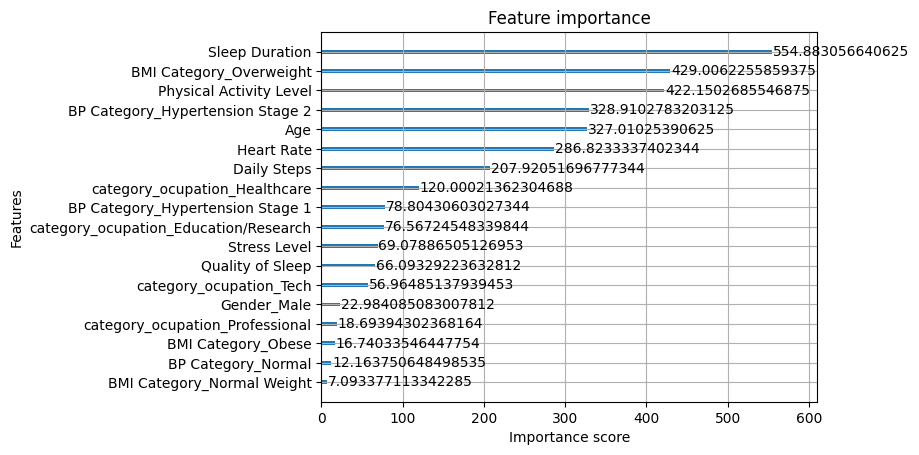

In [163]:
plot_importance(best_model, importance_type='total_gain')
plt.show()

**Model Random Forest**


In [164]:
threshold = 5
X_train_prep_copy = X_train_prep[best_feature_random[best_feature_random>threshold].index].copy()
X_test_prep_copy  = X_test_prep[best_feature_random[best_feature_random>threshold].index].copy()

In [165]:
model = RandomForestClassifier(**best_p)
model.fit(X_train_prep_copy, y_prep_train)
y_predic = model.predict(X_test_prep_copy)

In [166]:
score = recall_score(y_prep_test, y_predic, average='macro')
score

0.9696969696969697

**Model Random XGboost**

In [167]:
X_train_prep_copy = X_train_prep[['Sleep Duration', 'BMI Category_Overweight', 'Physical Activity Level', 'BP Category_Hypertension Stage 2', 'Age', 'Heart Rate', 'Daily Steps']].copy()
X_test_prep_copy  = X_test_prep[['Sleep Duration', 'BMI Category_Overweight', 'Physical Activity Level', 'BP Category_Hypertension Stage 2', 'Age', 'Heart Rate', 'Daily Steps']].copy()

In [168]:
best_model.fit(X_train_prep_copy, y_prep_train)
model.fit(X_train_prep_copy, y_prep_train)
y_predic = model.predict(X_test_prep_copy)

In [169]:
score = recall_score(y_prep_test, y_predic, average='macro')
score

0.9545454545454546

# **Utils**
---

In [170]:
def null_percentage_per_feature(data: pd.DataFrame, **kwargs) -> None:
    """
    Generate a horizontal distribution plot showing the percentage of null
    values per feature in a DataFrame.

    Parameters
    ----------
    data : pandas.DataFrame
        Input DataFrame used to compute null value percentages.

    **kwargs :
        Additional keyword arguments passed to seaborn.displot().set()
        for plot customization (e.g., title, labels).

    Returns
    -------
    None
        Does not return a value. Displays the null percentage distribution plot.
    """
    try:
        ticklabels = (
            data.isnull()
            .melt()
            .pipe(
                lambda df: sns.displot(
                    data=df,
                    y='variable',
                    hue='value',
                    multiple='fill',
                    aspect=5
                ).set(**kwargs)
            )
        )

        p = data.isnull().sum() / data.shape[0]

        for i, (feature, value) in enumerate(p.items()):
            if value > 0:
                ticklabels.ax.text(
                    value + 0.015,
                    i + 0.2,
                    f'{round(value * 100, 2)}%',
                    ha="center",
                    color='w',
                    fontweight='bold'
                )
    except Exception as e:
        print(e)


def plot_numeric_distributions(data: pd.DataFrame,
                               nrows: int = 3,
                               ncols: int = 3,
                               figsize: tuple = (9, 6),
                               fontsize_title: int = 12,
                               palette=None,
                               show_stats=None) -> None:

    """
    Plot histograms with KDE for all numeric features in a DataFrame.

    Parameters
    ----------
    data : pandas.DataFrame
        Input DataFrame containing numeric features to visualize.

    nrows : int, default=3
        Number of subplot rows.

    ncols : int, default=3
        Number of subplot columns.

    figsize : tuple, default=(9, 6)
        Figure size as (width, height).

    fontsize_title : int, default=12
        Font size for the main figure title.

    palette : None, str, list or dict
        - None → usa colores por defecto
        - str → nombre de paleta seaborn
        - list → lista de colores
        - dict → {"columna": "color"}

    show_stats : None, str or list, default=None
        - None → no muestra estadísticas
        - "all" → muestra mean, median y mode
        - list → ["mean", "median", "mode"]

    Returns
    -------
    None
        Does not return a value. Displays the distribution plots.
    """

    try:
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        axes = axes.flat

        numeric_columns = data.select_dtypes(include=np.number).columns

        if show_stats == "all":
            show_stats = ["mean", "median", "mode"]

        if palette is None:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        elif isinstance(palette, str):
            colors = sns.color_palette(palette, len(numeric_columns))
        elif isinstance(palette, list):
            colors = palette
        elif isinstance(palette, dict):
            colors = None
        else:
            raise ValueError("palette must be None, str, list or dict")

        for i, column in enumerate(numeric_columns):

            # Selección de color
            if isinstance(palette, dict):
                color = palette.get(
                    column,
                    plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]
                )
            else:
                color = colors[i % len(colors)]

            ax = axes[i]

            sns.histplot(
                data=data,
                x=column,
                stat="count",
                kde=True,
                color=color,
                ax=ax
            )

            if show_stats:
                series = data[column].dropna()

                if "mean" in show_stats:
                    ax.axvline(series.mean(), color="black", linestyle="--", label="Mean")

                if "median" in show_stats:
                    ax.axvline(series.median(), color="blue", linestyle=":", label="Median")

                if "mode" in show_stats and not series.mode().empty:
                    ax.axvline(series.mode().iloc[0], color="red", linestyle="-.", label="Mode")

                ax.legend(fontsize=7)

            ax.set_title(column, fontsize=10)
            ax.tick_params(labelsize=8)
            ax.set_xlabel("")

        fig.tight_layout()
        plt.subplots_adjust(top=0.9)
        fig.suptitle('Numeric Feature Distributions', fontsize=fontsize_title)

    except Exception as e:
        print(e)

def plot_categorical_donut_charts(data: pd.DataFrame,
                                   nrows: int = 1,
                                   ncols: int = 3,
                                   figsize: tuple = (9, 6),
                                   fontsize_title: int = 12,
                                   donut_width: float = 0.7,
                                   autopct_format: str = '%1.1f%%',
                                   c: dict=None) -> None:
  """
  Plot donut charts for all categorical (object) features in a DataFrame.

  Parameters
  ----------
  data : pandas.DataFrame
      Input DataFrame containing categorical features.

  nrows : int, default=1
      Number of subplot rows.

  ncols : int, default=3
      Number of subplot columns.

  figsize : tuple, default=(9, 6)
      Figure size as (width, height).

  fontsize_title : int, default=12
      Font size for the main figure title.

  donut_width : float, default=0.7
      Radius of the white circle to create donut effect.

  autopct_format : str, default='%1.1f%%'
      Format string for percentage labels.

  color_dict : dict, default=None
        Dictionary of colors per column

  Returns
  -------
  None
      Displays the donut charts.
  """

  fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
  ax = ax.flat

  category_columns = data.select_dtypes(include='object').columns

  for i, column in enumerate(category_columns):

      if i >= len(ax):
          break

      value_counts = data[column].value_counts()
      color_cycle = list(plt.rcParams['axes.prop_cycle'])
      if c and column in c:
        colors = [
            c[column].get(cat, 'gray')
            for cat in value_counts.index
            ]
      else:
        colors = [color_cycle[j % len(color_cycle)]["color"]
                  for j in range(len(data[column].value_counts()))]


      ax[i].pie(
          value_counts,
          labels=value_counts.index,
          autopct=lambda pct: f"{int(round(pct * sum(value_counts) / 100.0))} ({pct:1.1f}%)",
          colors=colors,
          textprops={'fontsize': 8}
      )

      # Donut effect
      centre_circle = plt.Circle((0, 0), donut_width, color='white')
      ax[i].add_artist(centre_circle)

      ax[i].set_title(column, fontsize=10)

  fig.tight_layout()
  plt.subplots_adjust(top=0.8)
  fig.suptitle('Categorical Feature Distribution', fontsize=fontsize_title)


def model_optimization(
    X:pd.DataFrame,
    y:pd.DataFrame,
    model:object,
    dict_params:dict)->dict:
    """
      Find the best combination of parameters for a random forest
      using the OOB score

      Args:
        X (DataFrame):      training data
        y (DataFrame)       labeled data
        model (object):     random forest regressor o Random forest classification
        dict_params (dict): dictionary with the best parameters

      Returns:
        dict: Best combination of parameters
    """
    try:
      results = {'params': [], 'metric': []}

      for params in dict_params:
        model_oobscore = model(**params)
        model_oobscore.fit(X, y)
        results['params'].append(params)
        results['metric'].append(model_oobscore.oob_score_)

      resultados_scores = pd.DataFrame(results)
      resultados_scores = pd.concat(
          [resultados_scores,
           resultados_scores['params'].apply(pd.Series)], axis=1)
      resultados_scores = resultados_scores.drop(columns = 'params')
      if isinstance(params['oob_score'], bool):
        pass
      else:
        resultados_scores['oob_score'] = resultados_scores['oob_score'].apply(
          lambda x: x.__name__)
      return resultados_scores
    except Exception as e:
      print(e)


# **Info**
---

**@By:** Steven Bernal

**@Nickname:** Kaiziferr

**@Git:** https://github.com/Kaiziferr